# Model comparison: nested-LOSO out-of-fold predictions

This notebook compares the **nested Leave-One-Subject-Out (LOSO) out-of-fold predictions** of the
three models trained in `logistic_regression_training.ipynb`, `decision_tree_training.ipynb`, and
`ANN_training.ipynb`. Each of those notebooks saves its pooled out-of-fold predictions
(`oof_true`, `oof_pred`, `oof_proba`) and per-individual fold metrics to a `.npz` file
(`results_logreg.npz`, `results_tree.npz`, `results_ann.npz`).

Because every one of the 168 rows has exactly one out-of-fold prediction from a model that never
saw that individual during training or tuning, these are honest held-out ("test set") predictions
for every individual — this is the basis for concluding which model generalizes best to a new
person.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
)

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

result_files = {
    "Logistic Regression": "results_logreg.npz",
    "Decision Tree": "results_tree.npz",
    "ANN": "results_ann.npz",
}

results = {name: dict(np.load(fname, allow_pickle=True)) for name, fname in result_files.items()}
list(results["ANN"].keys())

['model_name',
 'oof_true',
 'oof_pred',
 'oof_proba',
 'fold_individual',
 'fold_accuracy',
 'fold_balanced_accuracy']

## 1. Confusion matrices (nested LOSO out-of-fold predictions)

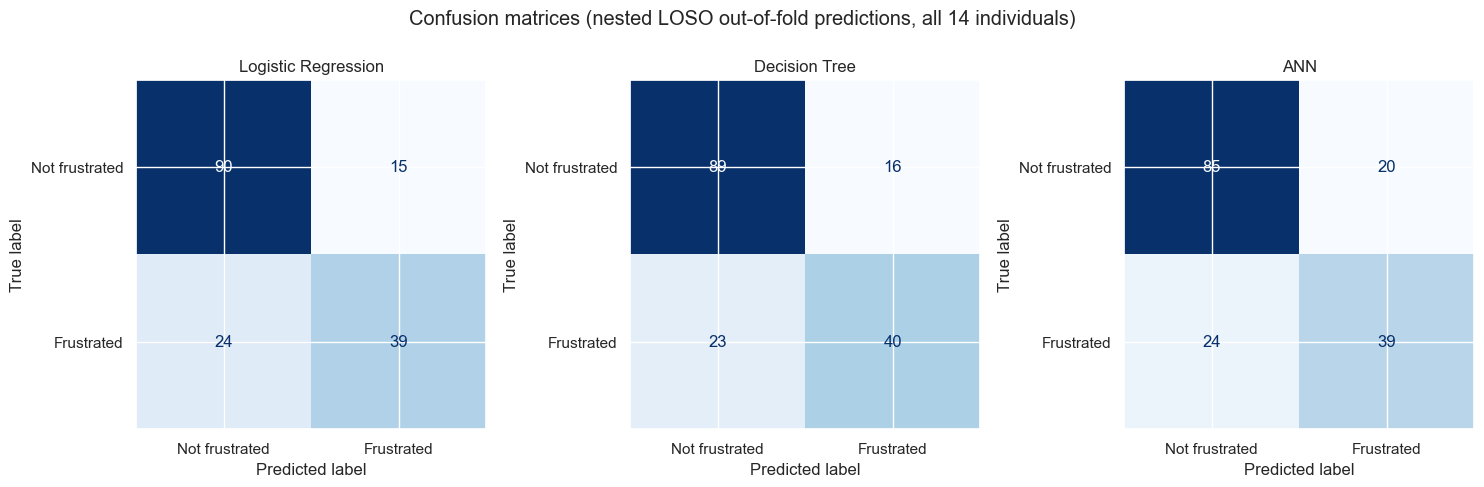

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["oof_true"], r["oof_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not frustrated", "Frustrated"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion matrices (nested LOSO out-of-fold predictions, all 14 individuals)")
plt.tight_layout()
plt.show()

## 2. Summary metrics

In [3]:
rows = []
for name, r in results.items():
    y_true, y_pred, y_proba = r["oof_true"], r["oof_pred"], r["oof_proba"]
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], zero_division=0
    )
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Precision (Frustrated)": precision[0],
        "Recall (Frustrated)": recall[0],
        "F1 (Frustrated)": f1[0],
    })

summary_df = pd.DataFrame(rows).set_index("Model")
summary_df.round(3)

,Accuracy,Balanced accuracy,ROC-AUC,Precision (Frustrated),Recall (Frustrated),F1 (Frustrated)
Model,,,,,,
Logistic Regression,0.768,0.738,0.773,0.722,0.619,0.667
Decision Tree,0.768,0.741,0.579,0.714,0.635,0.672
ANN,0.738,0.714,0.727,0.661,0.619,0.639


## 3. ROC curves

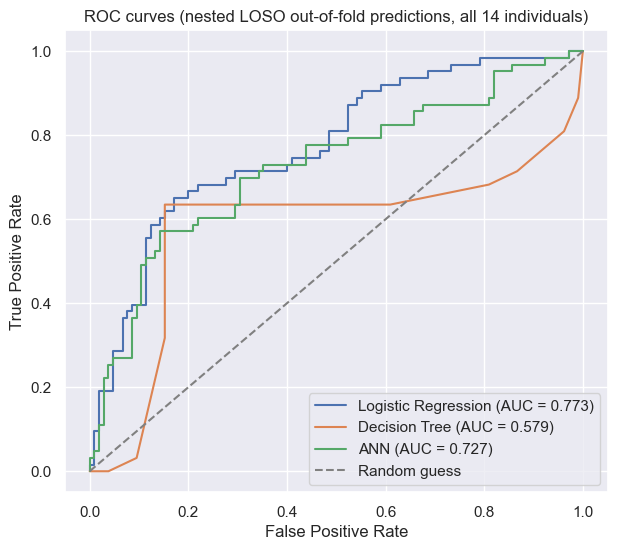

In [4]:
plt.figure(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r["oof_true"], r["oof_proba"])
    auc = roc_auc_score(r["oof_true"], r["oof_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (nested LOSO out-of-fold predictions, all 14 individuals)")
plt.legend()
plt.show()

## 4. Per-individual balanced accuracy

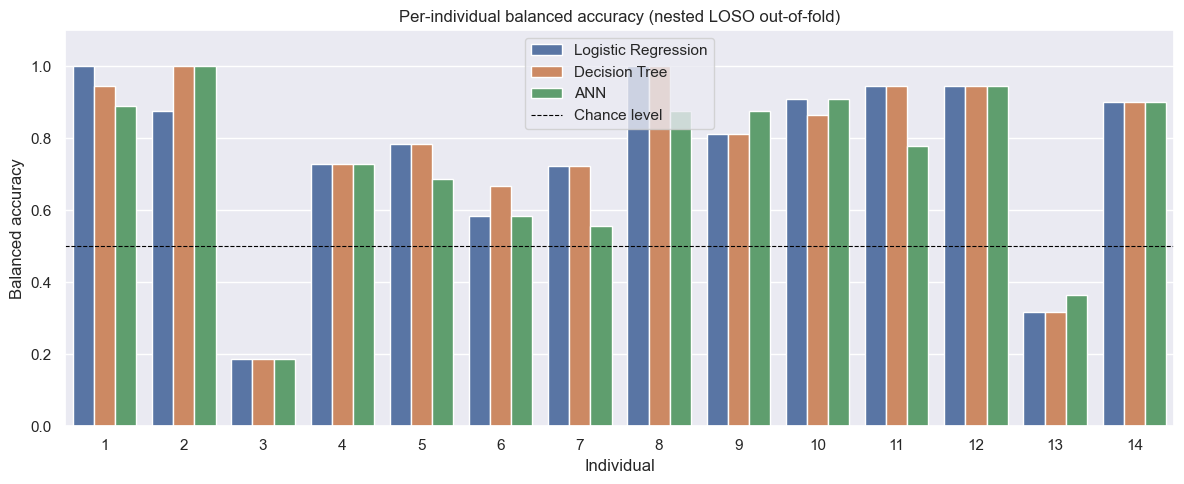

In [5]:
fold_long = pd.concat([
    pd.DataFrame({
        "Individual": r["fold_individual"],
        "Balanced accuracy": r["fold_balanced_accuracy"],
        "Model": name,
    })
    for name, r in results.items()
], ignore_index=True)

plt.figure(figsize=(12, 5))
sns.barplot(data=fold_long, x="Individual", y="Balanced accuracy", hue="Model")
plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Chance level")
plt.title("Per-individual balanced accuracy (nested LOSO out-of-fold)")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Statistical comparison: are the differences significant?

The summary metrics in Section 2 are computed on the **pooled** 168 out-of-fold predictions, but each individual contributes 12 of those rows, so they are not independent observations. For a fair statistical comparison we instead use the **14 per-individual balanced-accuracy scores** (one score per held-out individual, per model) — a natural **paired** design, since the same 14 individuals are evaluated by all three models.

Given the small sample size (n=14) and no reason to assume normally-distributed differences, we use a **paired Wilcoxon signed-rank test** for each pair of models.

In [6]:
from scipy.stats import wilcoxon
import itertools

# Per-individual balanced accuracy, aligned by Individual (paired design)
bal_acc_by_model = {
    name: pd.Series(r["fold_balanced_accuracy"], index=r["fold_individual"]).sort_index()
    for name, r in results.items()
}
aligned = pd.DataFrame(bal_acc_by_model)
print("Per-individual balanced accuracy:")
print(aligned.round(3))
print("\nMean per-individual balanced accuracy:")
print(aligned.mean().round(3))

print("\nPaired Wilcoxon signed-rank test on per-individual balanced accuracy:")
for m1, m2 in itertools.combinations(aligned.columns, 2):
    diff = aligned[m1] - aligned[m2]
    if (diff == 0).all():
        print(f"{m1} vs {m2}: identical per-individual scores (all 14 differences = 0)")
        continue
    stat, p = wilcoxon(aligned[m1], aligned[m2])
    print(f"{m1} vs {m2}: W = {stat:.3f}, p = {p:.3f}")

Per-individual balanced accuracy:
    Logistic Regression  Decision Tree    ANN
1                 1.000          0.944  0.889
2                 0.875          1.000  1.000
3                 0.188          0.188  0.188
4                 0.729          0.729  0.729
5                 0.786          0.786  0.686
6                 0.583          0.667  0.583
7                 0.722          0.722  0.556
8                 1.000          1.000  0.875
9                 0.812          0.812  0.875
10                0.909          0.864  0.909
11                0.944          0.944  0.778
12                0.944          0.944  0.944
13                0.318          0.318  0.364
14                0.900          0.900  0.900

Mean per-individual balanced accuracy:
Logistic Regression    0.765
Decision Tree          0.773
ANN                    0.734
dtype: float64

Paired Wilcoxon signed-rank test on per-individual balanced accuracy:
Logistic Regression vs Decision Tree: W = 3.000, p = 0.465
Logi

## 6. Conclusion: which model is best?

On the pooled nested-LOSO out-of-fold predictions (168 honest "held-out" predictions, one per
observation, each from a model that never saw that individual during training or tuning), all
three models are trained on the same fixed feature set: the **5 HR features** — `HR_Mean`,
`HR_Median`, `HR_std`, `HR_Max`, `HR_AUC` (see `feature_correlation_analysis.ipynb`; `HR_Min` is
excluded) — **plus one-hot encoded `Phase` and `Round`**. No automatic feature selection is used.

| Model | Accuracy | Balanced accuracy | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 0.768 | 0.738 | 0.773 |
| Decision Tree | 0.768 | 0.741 | 0.579 |
| ANN | 0.738 | 0.714 | 0.727 |

- **Logistic regression** has the best overall ROC-AUC (0.773) and ties the decision tree on
  accuracy/balanced accuracy (0.768/0.738). Its largest coefficient by far (Section 10 of
  `logistic_regression_training.ipynb`) is `Phase_phase2` (+2.43) — more than 2.5x the size of the
  next-largest coefficient (`Round_round_4`, +0.89) — followed by the HR features, where `HR_Mean`
  (+0.69) is the strongest.
- **The decision tree** matches logistic regression on accuracy (0.768) and balanced accuracy
  (0.741), but its ROC-AUC is much lower (0.579). All 14 outer folds select `max_depth = 1`, and
  the final tree (Section "Final decision tree") makes a **single split on `Phase_phase2`**, so
  `predict_proba` only returns 2 distinct values across all 168 predictions — this coarse, 2-level
  probability output limits how well the ROC curve can discriminate across thresholds, even though
  the hard 0/1 predictions at the default threshold are as accurate as logistic regression's.
- **The ANN** is close behind (0.738/0.714/0.727). Its permutation importance (Section 10 of
  `ANN_training.ipynb`) ranks `Phase` far above everything else (0.242, almost double the
  next-highest `HR_Mean` at 0.122), with `Round` contributing comparatively little (0.014) —
  consistent with the other two models.
- **Section 5 (paired Wilcoxon signed-rank test)** confirms that, despite these small differences,
  none of the pairwise comparisons reach conventional significance (p > 0.05 in every case, n=14)
  — the three models are statistically indistinguishable on this dataset, given how few
  individuals are available.

**Overall: with `Phase`/`Round` included alongside the 5 HR features, all three models predict
self-reported frustration well above chance** (balanced accuracy 0.71-0.74, vs. 0.50 for a coin
flip). Across all three models, **`Phase` (specifically `Phase_phase2`) is by far the single most
informative feature** — much more so than any individual HR feature — with `HR_Mean` a consistent
secondary contributor. `Round` and the remaining HR features (`HR_Median`, `HR_std`, `HR_Max`,
`HR_AUC`) add comparatively little on top of `Phase` + `HR_Mean`. Logistic regression and the
decision tree are essentially tied on accuracy/balanced accuracy, but logistic regression's smooth
probability output gives it a substantially better ROC-AUC; the ANN performs similarly to both. No
model shows a statistically decisive advantage given the small sample size (14 individuals) — all
three independently converge on the same dominant predictor (`Phase`), which is the most robust
finding of this analysis.